# 🌳 Breast Cancer Classification using Decision Trees
**Objective:** Classify breast cancer tumors as Malignant (M) or Benign (B) using a **Decision Tree Classifier**. 
**Crucial Note:** Unlike Distance-based algorithms (SVM, KNN), Tree-based models are **scale-invariant**. This means they do not require feature scaling (Standardization/Normalization) to perform well.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


---
### 📂 Step 1: Load Data & Clean
We drop the `id` and `Unnamed: 32` columns just like we did in the SVM model to ensure clean data input.

In [2]:
# Load Dataset
df = pd.read_csv('Cancer_Data (1).csv')

# Drop irrelevant/empty columns
columns_to_drop = ['id', 'Unnamed: 32']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head(3))

Cleaned Dataset Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


---
### ✂️ Step 2: Feature Separation & Target Encoding

In [3]:
# Separate Features (X) and Target (y)
X = df.drop('diagnosis', axis=1)
y_raw = df['diagnosis']

# Encode the Target variable: B -> 0, M -> 1
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Features Shape: {X_train.shape}")

Training Features Shape: (455, 30)


---
### 🏗️ Step 3: Build the Decision Tree Pipeline
Notice the absence of `StandardScaler`. Decision trees create axis-parallel splits, making them immune to the scale of the features. We limit the `max_depth` to 4 to prevent the tree from **overfitting** and to make it readable when we plot it.

In [4]:
# Build the Pipeline (Simpler because no scaling is needed!)
dt_pipeline = Pipeline(steps=[
    # max_depth=4 prevents the model from memorizing the data (Overfitting)
    ('classifier', DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)) 
])

print(" Decision Tree Pipeline Built Successfully")

 Decision Tree Pipeline Built Successfully


---
### 🚀 Step 4: Train, Evaluate, and Interpret
Decision trees are highly "interpretable." We can literally draw the tree to see the exact rules the AI learned to diagnose cancer.

🏆 Decision Tree Accuracy: 91.23%

📄 Classification Report (0 = Benign, 1 = Malignant):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        72
           1       0.94      0.81      0.87        42

    accuracy                           0.91       114
   macro avg       0.92      0.89      0.90       114
weighted avg       0.91      0.91      0.91       114



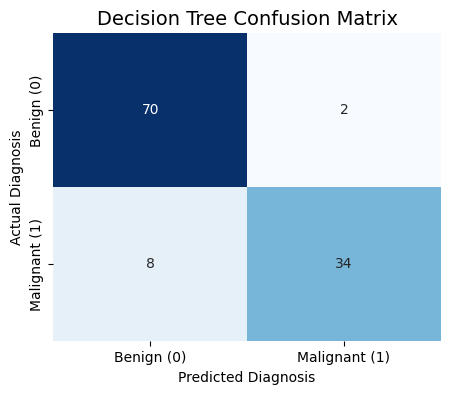

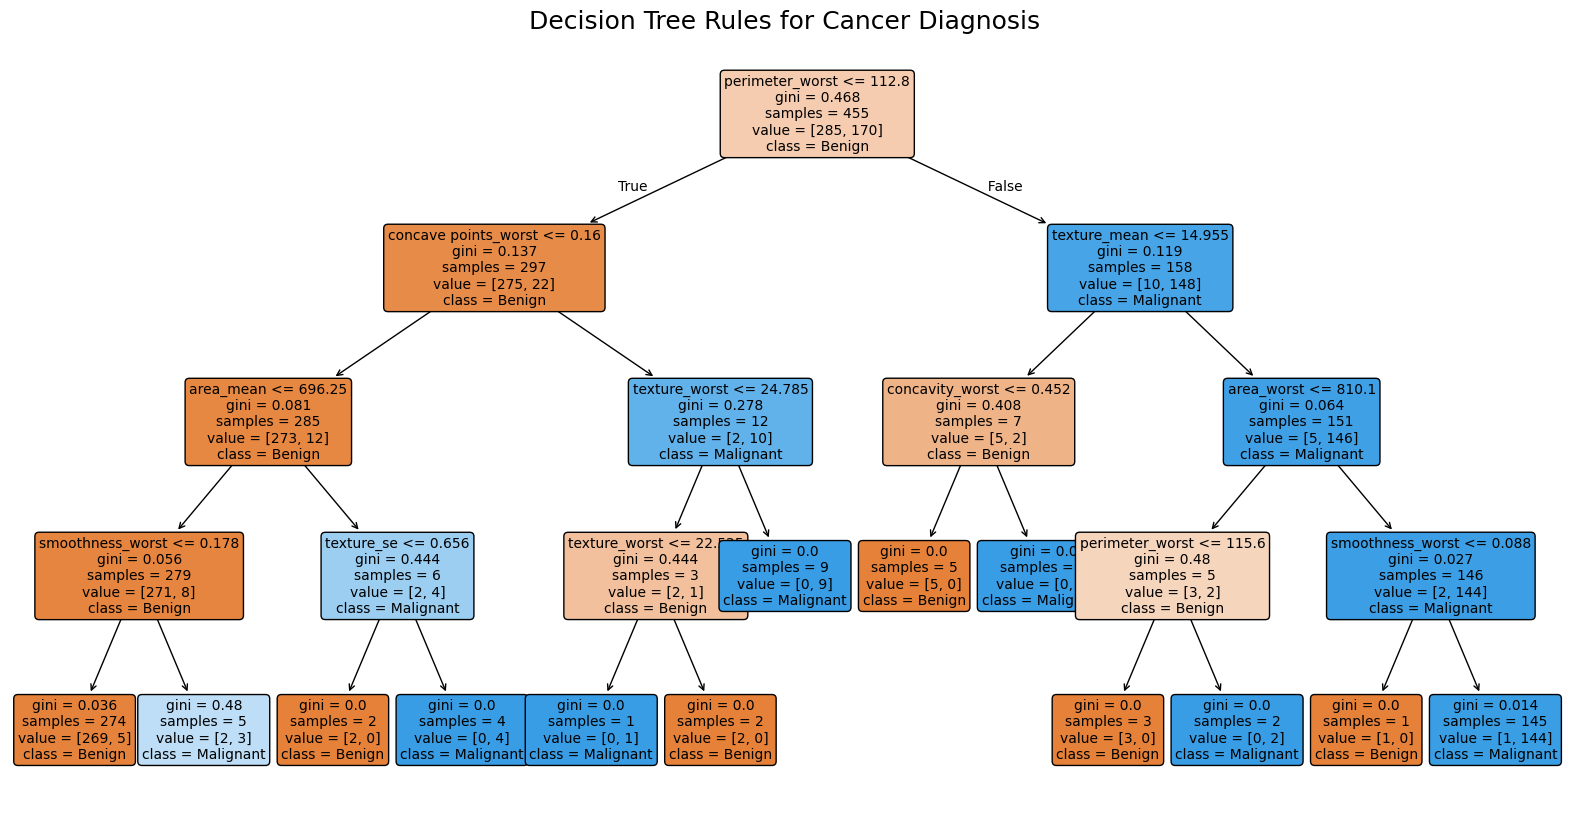

In [5]:
# Train the Pipeline
dt_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred = dt_pipeline.predict(X_test)

# 1. Evaluation Metrics
print(f"🏆 Decision Tree Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📄 Classification Report (0 = Benign, 1 = Malignant):")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Decision Tree Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# ==========================================
# 🌳 Visualizing the Decision Tree Logic
# ==========================================
plt.figure(figsize=(20, 10))

# Extract the trained tree model from the pipeline
trained_tree = dt_pipeline.named_steps['classifier']

plot_tree(trained_tree, 
          feature_names=X.columns,  
          class_names=['Benign', 'Malignant'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title('Decision Tree Rules for Cancer Diagnosis', fontsize=18)
plt.show()